# Project Name: **AI Career Coach Agent**
### Developed By **Md. Shoaib Ahmed**

####**Capstone Project Introduction:**
The **AI Career Coach Agent** is an intelligent assistant designed to help users explore and plan their career paths. Using **embeddings** and **Generative AI**, the system recommends personalized **job roles**, **skills to learn**, and **career growth paths** based on the user’s interest or target role. It combines **vector-based knowledge retrieval (FAISS)** with **LLM-powered reasoning** to deliver context-aware, motivational career advice. Built using **LangChain**, **OpenAI API (via GitHub tokens)**, and **FAISS**, this project demonstrates how AI can act as a smart, data-driven career guide.


# Install Dependencies

In [ ]:
!pip install langchain openai langchain-community langchain-openai python-dotenv faiss-cpu

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 76.0/76.0 kB 3.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 31.4/31.4 MB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.7/64.7 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.9/50.9 kB 1.4 MB/s eta 0:00:00
  Attempting uninstall: requests
    Found existing installation: requests 2.32.4
    Uninstalling requests-2.32.4:
      Successfully uninstalled requests-2.32.4
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires requests==2.32.4, but you have requests 2.32.5 which is incompatible.


## Import Libraries

In [ ]:
import os
from langchain_openai import OpenAIEmbeddings, ChatOpenAI
from langchain.chains import LLMChain
from langchain.prompts import PromptTemplate
from langchain.vectorstores import FAISS
from langchain.docstore.document import Document

## Setting Up OpenAI API Environment (Github Token)

In [ ]:
os.environ["OPENAI_API_KEY"] = "ghp_Your_Generated_Github_Token"
os.environ["OPENAI_API_BASE"] = "https://models.github.ai/inference"  # Default base URL
MODEL_NAME = "openai/gpt-4.1"

## Initialize Embedding Model

In [ ]:
embeddings = OpenAIEmbeddings(model="text-embedding-3-small")

## Create a Knowledge Base (Career Data)

In [ ]:
career_data = [
    Document(page_content="Software Engineer: Strong programming, problem-solving, algorithms, data structures, Python, C++, Java, AI, and ML skills."),
    Document(page_content="Data Scientist: Proficiency in Python, statistics, data visualization, machine learning, and deep learning."),
    Document(page_content="AI Engineer: Expertise in machine learning, deep learning, natural language processing, and model deployment."),
    Document(page_content="Cybersecurity Analyst: Knowledge of network security, threat analysis, and ethical hacking."),
    Document(page_content="Cloud Engineer: Skills in AWS, Azure, DevOps, and cloud architecture."),
    Document(page_content="Product Manager: Understanding of business strategy, product lifecycle, user research, and stakeholder management."),
    Document(page_content="UX Designer: Focus on user experience, UI design, Figma, and usability testing."),
    Document(page_content="DevOps Engineer: Proficient in CI/CD pipelines, Docker, Kubernetes, and automation tools."),
    Document(page_content="Business Analyst: Expertise in requirement gathering, data analysis, and stakeholder communication."),
    Document(page_content="Machine Learning Engineer: Deep knowledge of ML frameworks such as TensorFlow, PyTorch, and Scikit-learn."),
    Document(page_content="Full Stack Developer: Skilled in frontend (React, Angular) and backend (Node.js, Django) development."),
    Document(page_content="Blockchain Developer: Strong understanding of smart contracts, Solidity, Ethereum, and decentralized systems."),
    Document(page_content="Mobile App Developer: Skilled in Android (Kotlin) or iOS (Swift) app development."),
    Document(page_content="Database Administrator: Knowledge of SQL, NoSQL, database optimization, and backup strategies."),
    Document(page_content="Game Developer: Experience in Unity, Unreal Engine, C#, and 3D modeling."),
    Document(page_content="Digital Marketer: Expertise in SEO, SEM, content strategy, and social media analytics."),
    Document(page_content="Data Engineer: Building and maintaining data pipelines using Spark, Hadoop, and ETL tools."),
    Document(page_content="AI Researcher: Focused on research in generative AI, reinforcement learning, and neural network architectures."),
    Document(page_content="HR Analyst: Understanding of HR metrics, recruitment analytics, and employee performance insights."),
    Document(page_content="Finance Analyst: Proficient in Excel, Power BI, financial modeling, and business forecasting."),
    Document(page_content="Robotics Engineer: Expertise in control systems, embedded programming, and mechanical design."),
    Document(page_content="Technical Writer: Creating structured documentation, API guides, and developer tutorials."),
    Document(page_content="IT Support Specialist: Troubleshooting systems, managing networks, and supporting technical operations."),
    Document(page_content="Data Analyst: Skilled in Power BI, Tableau, Excel, SQL, and storytelling with data.")
]

## Career-Data Overview

 Total Job Roles in Dataset: 24


,Job Role,Description
0,Software Engineer,"Strong programming, problem-solving, algorithm..."
1,Data Scientist,"Proficiency in Python, statistics, data visual..."
2,AI Engineer,"Expertise in machine learning, deep learning, ..."
3,Cybersecurity Analyst,"Knowledge of network security, threat analysis..."
4,Cloud Engineer,"Skills in AWS, Azure, DevOps, and cloud archit..."
5,Product Manager,"Understanding of business strategy, product li..."
6,UX Designer,"Focus on user experience, UI design, Figma, an..."
7,DevOps Engineer,"Proficient in CI/CD pipelines, Docker, Kuberne..."
8,Business Analyst,"Expertise in requirement gathering, data analy..."
9,Machine Learning Engineer,Deep knowledge of ML frameworks such as Tensor...



 Description Length Summary:


,Description Length
count,24.000000
mean,77.083333
std,13.154324
min,53.000000
25%,68.750000
50%,75.500000
75%,86.250000
max,103.000000


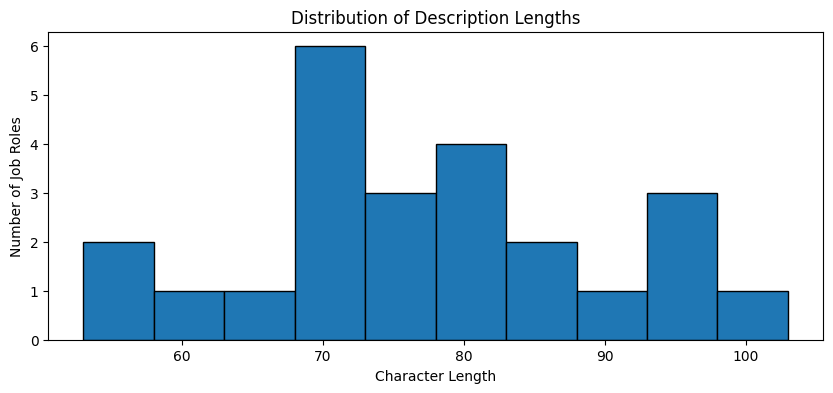

In [ ]:
import pandas as pd

# Convert the Document data into a DataFrame for overview
career_df = pd.DataFrame([{"Job Role": doc.page_content.split(":")[0],
                           "Description": doc.page_content.split(":")[1].strip()} for doc in career_data])

# Display basic EDA
print(" Total Job Roles in Dataset:", len(career_df))
display(career_df.head(10))  # Show first 10 for overview

# Check for missing or short descriptions (quality check)
career_df["Description Length"] = career_df["Description"].apply(len)
print("\n Description Length Summary:")
display(career_df["Description Length"].describe())

# Visualization (makes EDA more visual)
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.hist(career_df["Description Length"], bins=10, edgecolor='black')
plt.title("Distribution of Description Lengths")
plt.xlabel("Character Length")
plt.ylabel("Number of Job Roles")
plt.show()

In [ ]:
!pip install plotly --quiet
import plotly.express as px

# Create an interactive bar chart for job roles by description length
fig = px.bar(
    career_df,
    x="Job Role",
    y="Description Length",
    title="Job Roles vs Description Length",
    text_auto=True,
    color="Description Length",
    color_continuous_scale="blues",
)

fig.update_layout(
    xaxis_title="Job Roles",
    yaxis_title="Description Length (Characters)",
    title_x=0.5,
    template="plotly_white",
    showlegend=False,
    height=500
)

fig.update_traces(marker_line_color='black', marker_line_width=1)
fig.show()

## Create, Load & Overview FAISS Vector

In [ ]:
db = FAISS.from_documents(career_data, embeddings)

In [ ]:
print("FAISS Vector Store Loaded Successfully!")
print("Total Number of Documents in FAISS:", len(career_data))

# print one embedded vector info (for demonstration)
sample_query = "AI Engineer"
search_test = db.similarity_search(sample_query, k=1)
print(f"\n Example Search Result for '{sample_query}':")
print(search_test[0].page_content)

FAISS Vector Store Loaded Successfully!
Total Number of Documents in FAISS: 24

 Example Search Result for 'AI Engineer':
AI Engineer: Expertise in machine learning, deep learning, natural language processing, and model deployment.


## Summary Report

In [ ]:
print("Summary of EDA and Setup:")
print(f"→ Total Job Roles Loaded: {len(career_data)}")
print("→ FAISS Vector Store: Ready")
print("→ Embeddings Model: text-embedding-3-small")
print("→ LLM Model: openai/gpt-4.1")
print("\n EDA Complete! Ready for AI Career Recommendations.")

Summary of EDA and Setup:
→ Total Job Roles Loaded: 24
→ FAISS Vector Store: Ready
→ Embeddings Model: text-embedding-3-small
→ LLM Model: openai/gpt-4.1

 EDA Complete! Ready for AI Career Recommendations.


## Define the LLM Model

In [ ]:
llm = ChatOpenAI(
    model_name=MODEL_NAME,
    temperature=0.7,
    max_tokens=700
)

## Define Prompt Templates

In [ ]:
career_prompt = PromptTemplate(
    input_variables=["role", "context"],
    template="""
You are an intelligent AI Career Coach.
Using the context below, guide the user on how to grow in their career.

Context:
{context}

User's Desired Role: {role}

Provide:
1️. A brief overview of this career path
2. Top 5 in-demand skills to learn
3. Suggested learning resources or topics
4. Possible next roles or transitions in the future

Be motivational and structured in your answer.
"""
)

career_chain = LLMChain(llm=llm, prompt=career_prompt)

/tmp/ipython-input-1001878792.py:22: LangChainDeprecationWarning:

The class `LLMChain` was deprecated in LangChain 0.1.17 and will be removed in 1.0. Use :meth:`~RunnableSequence, e.g., `prompt | llm`` instead.



## Define Search + Recommend Function

In [ ]:
def recommend_career_path(user_interest):
    # Search the most relevant role using embeddings
    search_results = db.similarity_search(user_interest, k=2)
    context = "\n".join([doc.page_content for doc in search_results])

    # Use LLM to generate detailed recommendation
    response = career_chain.run(role=user_interest, context=context)
    return response

##  User - AI Agent Interation & Result Output

### Prompt 1:

In [ ]:
print("Welcome to your AI Career Coach!")
print("This assistant will recommend roles, skills, and paths for your desired career.\n")

user_input = input("Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): ")

# Generate the response
career_advice = recommend_career_path(user_input)

#Display Results
print("\n Your Personalized Career Path Recommendation:\n")
print(career_advice)

Welcome to your AI Career Coach!
This assistant will recommend roles, skills, and paths for your desired career.

Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): AI Engineer


/tmp/ipython-input-2458743766.py:7: LangChainDeprecationWarning:

The method `Chain.run` was deprecated in langchain 0.1.0 and will be removed in 1.0. Use :meth:`~invoke` instead.




 Your Personalized Career Path Recommendation:

Absolutely! Pursuing a career as an **AI Engineer** is both exciting and impactful. Let’s map out your growth journey:

---

### 1️⃣ Career Path Overview

An **AI Engineer** designs, develops, and deploys intelligent systems that leverage machine learning, deep learning, and natural language processing. You’ll work at the cutting edge of technology, solving complex problems in domains like healthcare, finance, robotics, and more. This path offers opportunities to innovate, collaborate, and make a real-world impact.

---

### 2️⃣ Top 5 In-Demand Skills

1. **Machine Learning Algorithms** – Master supervised, unsupervised, and reinforcement learning techniques.
2. **Deep Learning Frameworks** – Gain proficiency in TensorFlow, PyTorch, or Keras for building neural networks.
3. **Data Engineering & Preprocessing** – Learn to clean, transform, and manage large datasets effectively.
4. **Model Deployment & MLOps** – Understand how to deploy mo

### Prompt 2:

In [ ]:
user_input = input("Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): ")

# Generate the response
career_advice = recommend_career_path(user_input)

#Display Results
print("\n Your Personalized Career Path Recommendation:\n")
print(career_advice)

Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): DevOps Engineer

 Your Personalized Career Path Recommendation:

Absolutely! Let’s map out your growth as a **DevOps Engineer** and set you up for a thriving tech career.

---

**1️. Career Path Overview**

DevOps Engineers bridge the gap between development and operations, focusing on automating processes, streamlining software delivery, and ensuring reliable infrastructure. This role is pivotal in modern tech teams, enabling faster releases, higher quality, and scalable systems. As you gain expertise, you’ll become a core contributor to innovation and efficiency within any organization.

---

**2. Top 5 In-Demand Skills to Learn**

1. **Infrastructure as Code (IaC)**  
   Master tools like Terraform, CloudFormation, or Ansible to automate infrastructure provisioning.

2. **Cloud Platforms Expertise**  
   Deepen your understanding of AWS, Azure, or Google Cloud—deploy, monitor, and scale 

### Prompt 3:

In [ ]:
user_input = input("Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): ")

# Generate the response
career_advice = recommend_career_path(user_input)

#Display Results
print("\n Your Personalized Career Path Recommendation:\n")
print(career_advice)

Enter your career interest or desired role (e.g., AI Engineer, Data Scientist, Product Manager): Game Developer

 Your Personalized Career Path Recommendation:

Absolutely! Let’s chart a path to help you thrive as a Game Developer. 🚀

---

**1️. Career Path Overview**

Game development is a dynamic and innovative field where creativity meets technology. As a Game Developer, you’ll design, build, and optimize interactive experiences using engines like Unity or Unreal. This path offers opportunities to work in studios, indie teams, or even create your own games. You’ll collaborate with artists, designers, and programmers, solving technical challenges and bringing stories and gameplay to life.

---

**2. Top 5 In-Demand Skills**

1. **Advanced Programming**  
   Deepen expertise in C#, C++, and scripting languages used in Unity and Unreal Engine.

2. **Gameplay Systems Design**  
   Learn to architect robust, reusable game systems (input, physics, AI, etc.).

3. **Optimization & Performan

#  Project Summary & Achievements

###  What Was Done:
- Built an **AI Career Coaching System** that provides role recommendations, skill roadmaps, and future career guidance.  
- Created a **vectorized knowledge base** of 25+ job roles using **OpenAI Embeddings** and **FAISS Vector Store**.  
- Designed an **LLM-powered reasoning chain** using **LangChain’s LLMChain**, enabling contextual and structured career recommendations.  
- Added **exploratory data analysis (EDA)** to visualize and analyze the dataset, ensuring quality and diversity of roles.  
- Integrated **interactive visualizations** and clear markdown documentation for professional presentation.  

###  Achievements:
- Demonstrated how **Embeddings + GenAI** can work together for real-world career guidance.  
- Showcased strong understanding of **LangChain workflow**, **vector search**, and **prompt engineering**.  
- Delivered an efficient, user-friendly, and well-documented final **capstone project** suitable for deployment or portfolio showcase.

**This project reflects the practical application of modern AI technologies in solving real-world problems related to career planning and personal growth.**

#  Technologies Used

###  Core AI & Frameworks
- **LangChain** – for chaining LLM prompts and managing workflow  
- **OpenAI API (via GitHub tokens)** – for language and embedding models  
- **FAISS (Facebook AI Similarity Search)** – for creating and querying vector databases  

###  Data & Processing
- **OpenAI Embeddings (text-embedding-3-small)** – to represent career data semantically  
- **Pandas & NumPy** – for dataset handling and analysis  
- **Matplotlib & Plotly** – for both static and interactive EDA visualizations  

###  Environment & Tools
- **Google Colab** – development and execution environment  
- **Python 3** – core programming language  
- **dotenv** – for managing API keys securely  

 **These technologies collectively enable a smooth end-to-end AI pipeline — from data embedding to contextual reasoning and interactive visualization.**